# Production of Movies in Fast-light and Slow-light modes

## AART Importation

In [1]:
import os
import sys
import platform
# Original path
sistema = platform.system()
print(f"Estás en: {sistema}")

if sistema == "Windows":
    ruta_original = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\VariabilityOfBlackHoleLightCurves"
elif sistema == "Linux":
    ruta_original = r"Linux path"
else:
    print(f"No pude identificar el sistema: {sistema}")
    
print(f"Ruta original: {ruta_original}")

# Path of aart_main
if sistema == "Windows":
    ruta_aart =r'C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main'
elif sistema == "Linux":
    ruta_aart == r"Linux path"
else:
    print(f"No pude identificar el sistema: {sistema}")
    
ruta_aart_main = os.path.join(ruta_original,ruta_aart)
print(f"Ruta de aart_main: {ruta_aart_main}")

# Change the working directory so that Python thinks you are inside aart_main
os.chdir(ruta_aart_main)
print(f"Ruta actual después de cambio: {os.getcwd()}")

# put the original path to sys.path for use aart_main 
if ruta_original not in sys.path:
    sys.path.append(ruta_original)
    print(f"Agregado a sys.path: {ruta_original}")

## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *

Estás en: Windows
Ruta original: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\VariabilityOfBlackHoleLightCurves
Ruta de aart_main: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main
Ruta actual después de cambio: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main

Thanks for using AART


## Importacion de contenido en LensingBandas y RayTracing

In [14]:
fnbands = path + "LensingBands_a_%s_i_%s.h5"%(spin_case,i_case)
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

alpha_critic = h5f['alpha'][:]
beta_critic  = h5f['beta'][:]
hull_0i=h5f['hull_0i'][:]
hull_0e=h5f['hull_0e'][:]
hull_1i=h5f['hull_1i'][:]
hull_1e=h5f['hull_1e'][:]
hull_2i=h5f['hull_2i'][:]
hull_2e=h5f['hull_2e'][:]

supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
lim0=int(h5f["lim0"][0])

supergrid1=h5f['grid1'][:]
N1=int(h5f["N1"][0])
mask1=h5f['mask1'][:]
lim1=int(h5f["lim1"][0])

supergrid2=h5f['grid2'][:]
N2=int(h5f["N2"][0])
mask2=h5f['mask2'][:]
lim2=int(h5f["lim2"][0])

h5f.close()


reading file: ./Results/LensingBands_a_0.94_i_17.h5


In [20]:
fnrays="./Results/Rays_a_%s_i_%s.h5"%(spin_case,i_case)
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  ./Results/Rays_a_0.94_i_17.h5


## Inoisy File

### Inoisy.py elements

In [29]:
# Esta es la función que se llama en cada visita del árbol
def print_h5_structure(name, obj):
    print(name)

with h5py.File('inoisy.h5', 'r') as inoisyfile:
    print("Estructura completa del archivo inoisy.h5:")
    inoisyfile.visititems(print_h5_structure)

Estructura completa del archivo inoisy.h5:
data
data/data_env
data/lightcurve_env
data/lightcurve_raw
params
params/armangle
params/betaphi
params/betar
params/dx1
params/dx2
params/gammap
params/mup
params/sigmap
params/spatialcorr
params/spatialcorrxy
params/spin
params/sub_kep
params/x0end
params/x0start
params/x1end
params/x1start
params/x2end
params/x2start


### Lecture of inoisy file

In [14]:
#Abres el documento que ya se encuentra en el repositorio
inoisyfile = h5py.File("inoisy.h5", 'r')
i_fname="inoisy.h5"
print(f'el archivo inoisy.h5 contiene los siguientes directorios: \n', list(inoisyfile.keys()))

# Lecuture of inoisy
data = np.array(inoisyfile['data/data_env'])

data_lc = np.array(inoisyfile['data/lightcurve_env'])
dataclean_lc = np.array(inoisyfile['data/lightcurve_raw']) 

#Limits of the figure
xystart = np.array(inoisyfile['params/x1start'])[0]

print("There are %s snapshots in this inoisy data set"%data.shape[0])
inoisyfile.close()

el archivo inoisy.h5 contiene los siguientes directorios: 
 ['data', 'params']
There are 257 snapshots in this inoisy data set


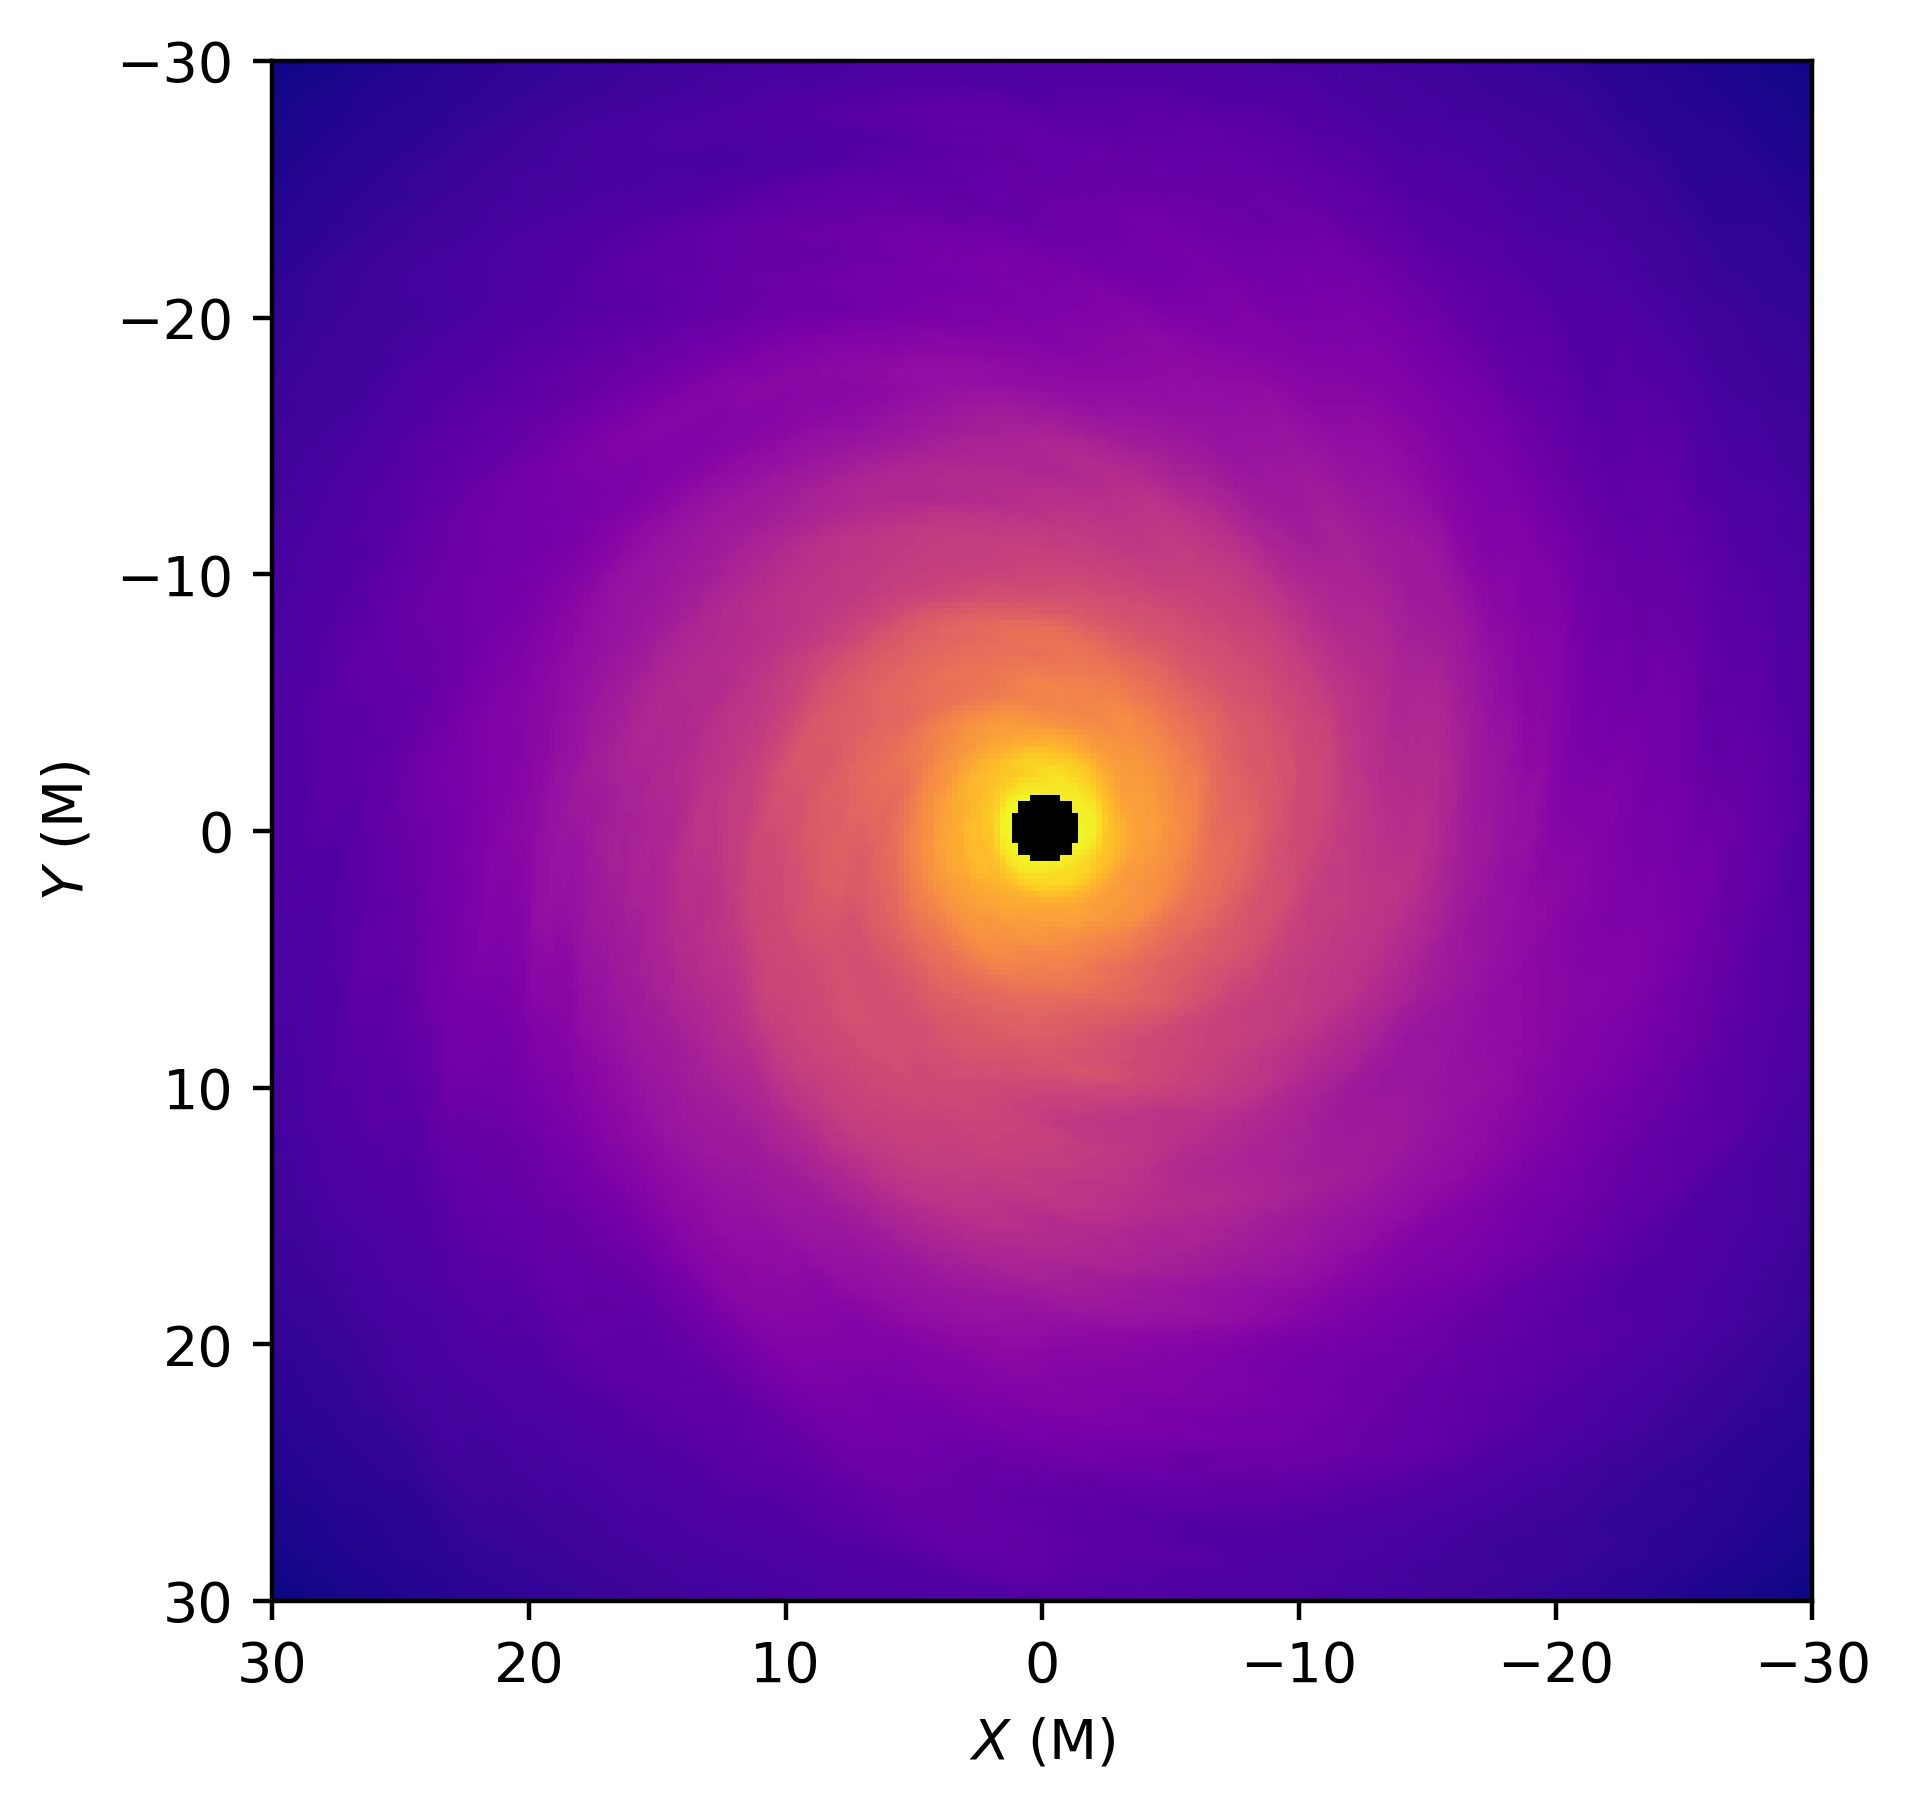

In [9]:
fig, ax = plt.subplots(figsize=[5,5],dpi=400)

#You can select different snapshots by changing the slicing 
ax.imshow(np.log(data[55,:,:]),cmap="plasma",origin="lower",extent=[-xystart,xystart,-xystart,xystart])

ax.set_facecolor('xkcd:black')
ax.set_xlabel(r"$X$"+" "+"(M)")
ax.set_ylabel(r"$Y$"+" "+"(M)")
#plt.savefig(f'InoisySnapshot.png',dpi=400,bbox_inches='tight')
plt.show()

### Movie with inoisy

In [ ]:
fignames=[]
VMAX=np.max(data)
for tsnap in np.arange(snapshots):
    fig, ax = plt.subplots()
    
    ax.imshow(data[tsnap,:,:],origin="lower",cmap="plasma",extent=[-lim0,lim0,-lim0,lim0])
    ax.set_xlim(-10,10)
    ax.set_ylim(-10,10)
    
    ax.set_xlabel(r"$\alpha$"+" "+"(M)")
    ax.set_ylabel(r"$\beta$"+" "+"(M)")
    
    fignames.append('./Results/Movies/Fig%s.png'%tsnap)
    plt.savefig('./Results/Movies/Fig%s.png'%tsnap,dpi=400,bbox_inches='tight')
    plt.close(fig)

with imageio.get_writer('./Results/Movies/BHMovie_Inoisy.gif', mode='I') as writer:
    for filename in fignames:
        image = imageio.imread(filename)
        writer.append_data(image)

# We delete the created images and just keep the GIF
for filename in set(fignames):
    os.remove(filename)

## Slow-light Movie Production

### Data of the movie production using iMovies.py

In [16]:
fimages="./Results/Images_a_%s_i_%s_%s"%(spin_case,i_case,i_fname)

print("Reading file: ",fimages)

h5f = h5py.File(fimages,'r')

Is0=h5f['bghts0'][:]
Is1=h5f['bghts1'][:]
Is2=h5f['bghts2'][:]
h5f.close()

Reading file:  ./Results/Images_a_0.94_i_17_inoisy.h5


### Movie with inoisy + AART in Slow-light mode

In [ ]:
fignames=[]
VMAX=np.max(Is0+Is1+Is2)
for tsnap in np.arange(snapshots):
    fig, ax = plt.subplots()
    
    ax.imshow(Is0[tsnap,:,:]+Is1[tsnap,:,:]+Is2[tsnap,:,:],vmax=VMAX,origin="lower",cmap="plasma",extent=[-lim0,lim0,-lim0,lim0])

    ax.set_xlabel(r"$\alpha$"+" "+"(M)")
    ax.set_ylabel(r"$\beta$"+" "+"(M)")
    
    fignames.append('./Results/Movies/Fig%s.png'%tsnap)
    plt.savefig('./Results/Movies/Fig%s.png'%tsnap,dpi=400,bbox_inches='tight')
    plt.close(fig)

with imageio.get_writer('./Results/Movies/BHMovie.gif', mode='I') as writer:
    for filename in fignames:
        image = imageio.imread(filename)
        writer.append_data(image)

# We delete the created images and just keep the GIF
for filename in set(fignames):
    os.remove(filename)

### Light-Curve 

In [17]:
Light_curve_aart = np.zeros(snapshots)
Itotal = Is0 + Is1 + Is2
for tsnap in range(snapshots):
    Light_curve_aart[tsnap] = np.sum(Is0[tsnap,:,:]) + np.sum(Is1[tsnap,:,:]) + np.sum(Is2[tsnap,:,:])
Max_Light_aart_curve = np.max(Light_curve_aart)

Light_NormalCurve_aart = Light_curve_aart/(Max_Light_aart_curve +0.2*Max_Light_aart_curve)

T_LightCurve_arrt = np.linspace(i_tM,f_tM,snapshots)

In [18]:
Light_curve = np.zeros(256)
for tsnap in range(256):
    Light_curve[tsnap] = np.sum(data[tsnap])

Light_MCurve = Light_curve/np.max(Light_curve)

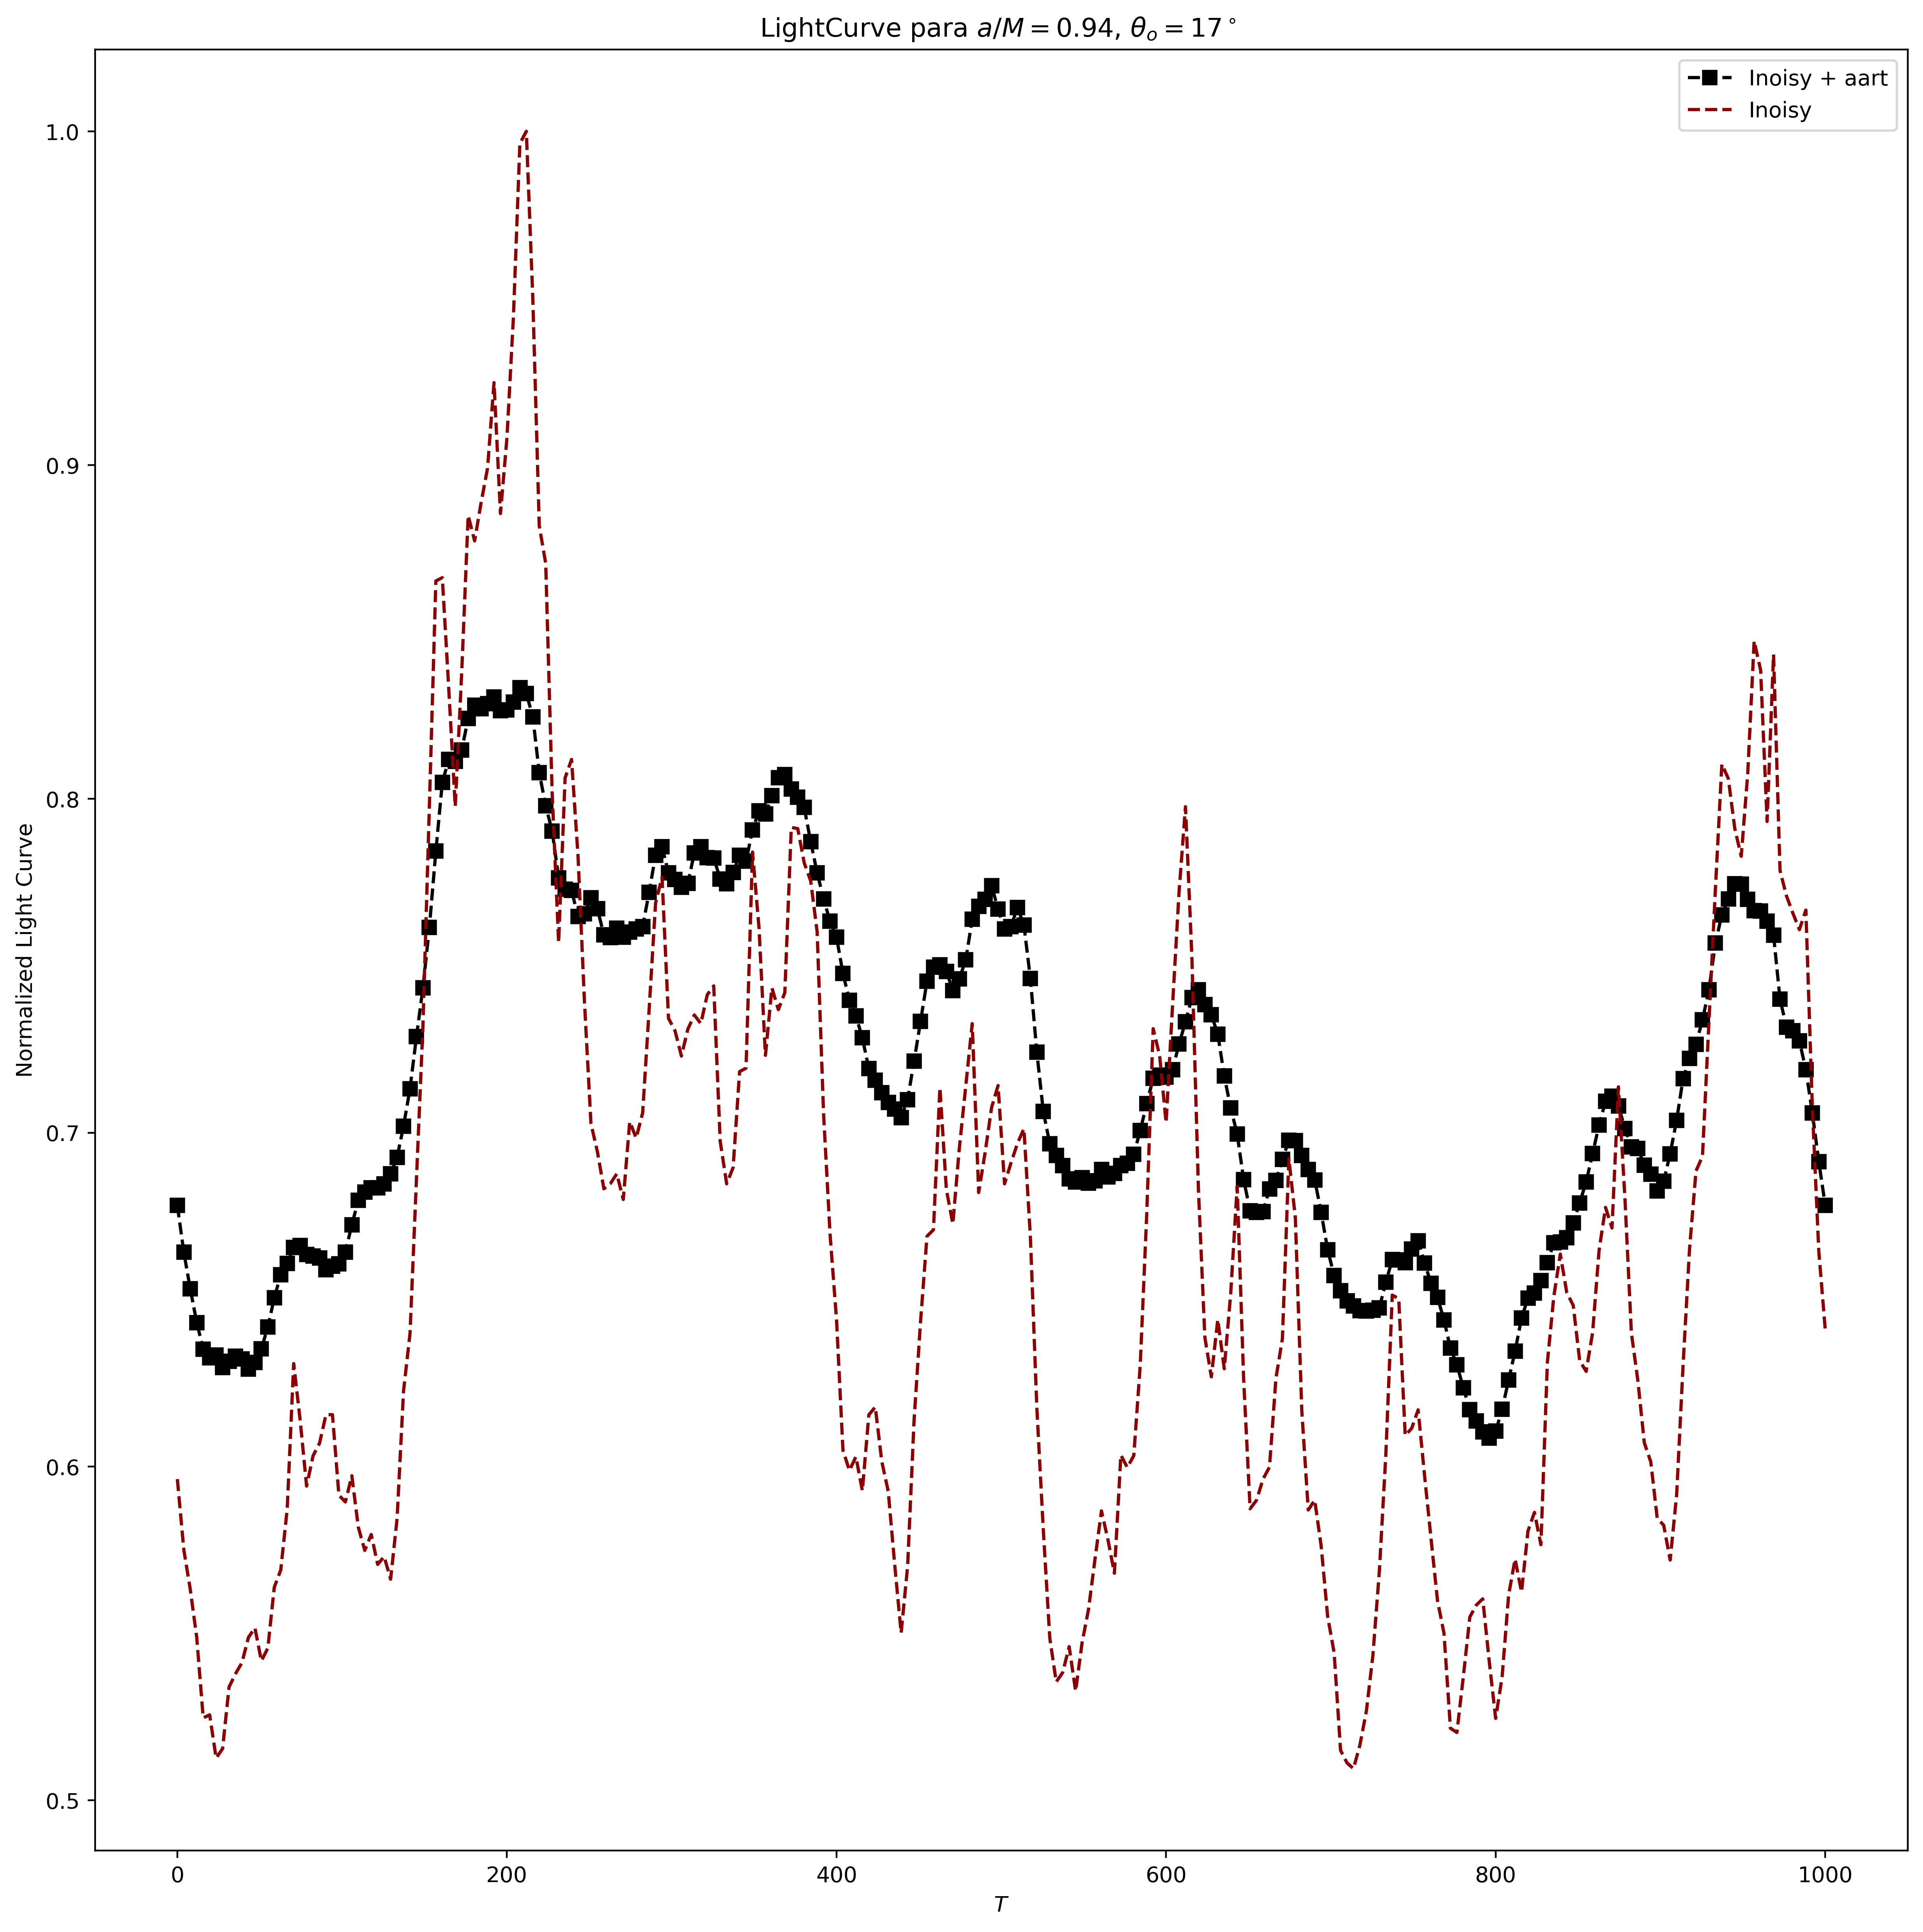

In [14]:
plt.figure(figsize=(15,15),dpi=400)

plt.plot(T_LightCurve_arrt,Light_NormalCurve_aart, 's--r', label ='Inoisy + aart' , color = 'k')
plt.plot(np.linspace(i_tM,f_tM,256),Light_MCurve, linestyle="--", label ='Inoisy' , color = 'darkred')
plt.xlabel(r"$T$")
plt.ylabel(r"Normalized Light Curve")
plt.title(rf'LightCurve para $a/M = {spin_case}$, $\theta_o = {i_case}^\circ$ ')
plt.legend()
#plt.savefig(f"./Results/Imagenes/LightCurve_{spin_case}_{i_case}_1.png",dpi=400,bbox_inches='tight')
plt.show()

## Fast-light Movie Production

In [8]:
fimages="./Results/FastLight_Images_a_%s_i_%s_%s"%(spin_case,i_case,i_fname)

print("Reading file: ",fimages)

h5f = h5py.File(fimages,'r')

I0=h5f['bghts0'][:]
I1=h5f['bghts1'][:]
I2=h5f['bghts2'][:]

print(f'el archivo {fimages} contiene los siguientes directorios: \n', list(h5f.keys()))

h5f.close() 

Reading file:  ./Results/FastLight_Images_a_0.94_i_17_inoisy.h5
el archivo ./Results/FastLight_Images_a_0.94_i_17_inoisy.h5 contiene los siguientes directorios: 
 ['bghts0', 'bghts1', 'bghts2']


In [9]:
Light_curve_fast = np.zeros(snapshots)
for tsnap in range(snapshots):
    Light_curve_fast[tsnap] = np.sum(I0[tsnap,:,:]) + np.sum(I1[tsnap,:,:]) + np.sum(I2[tsnap,:,:])
    
Max_Light_fast_curve = np.nanmax(Light_curve_fast)

Light_NormalCurve_fast = Light_curve_fast/(Max_Light_fast_curve +0.2*Max_Light_fast_curve)


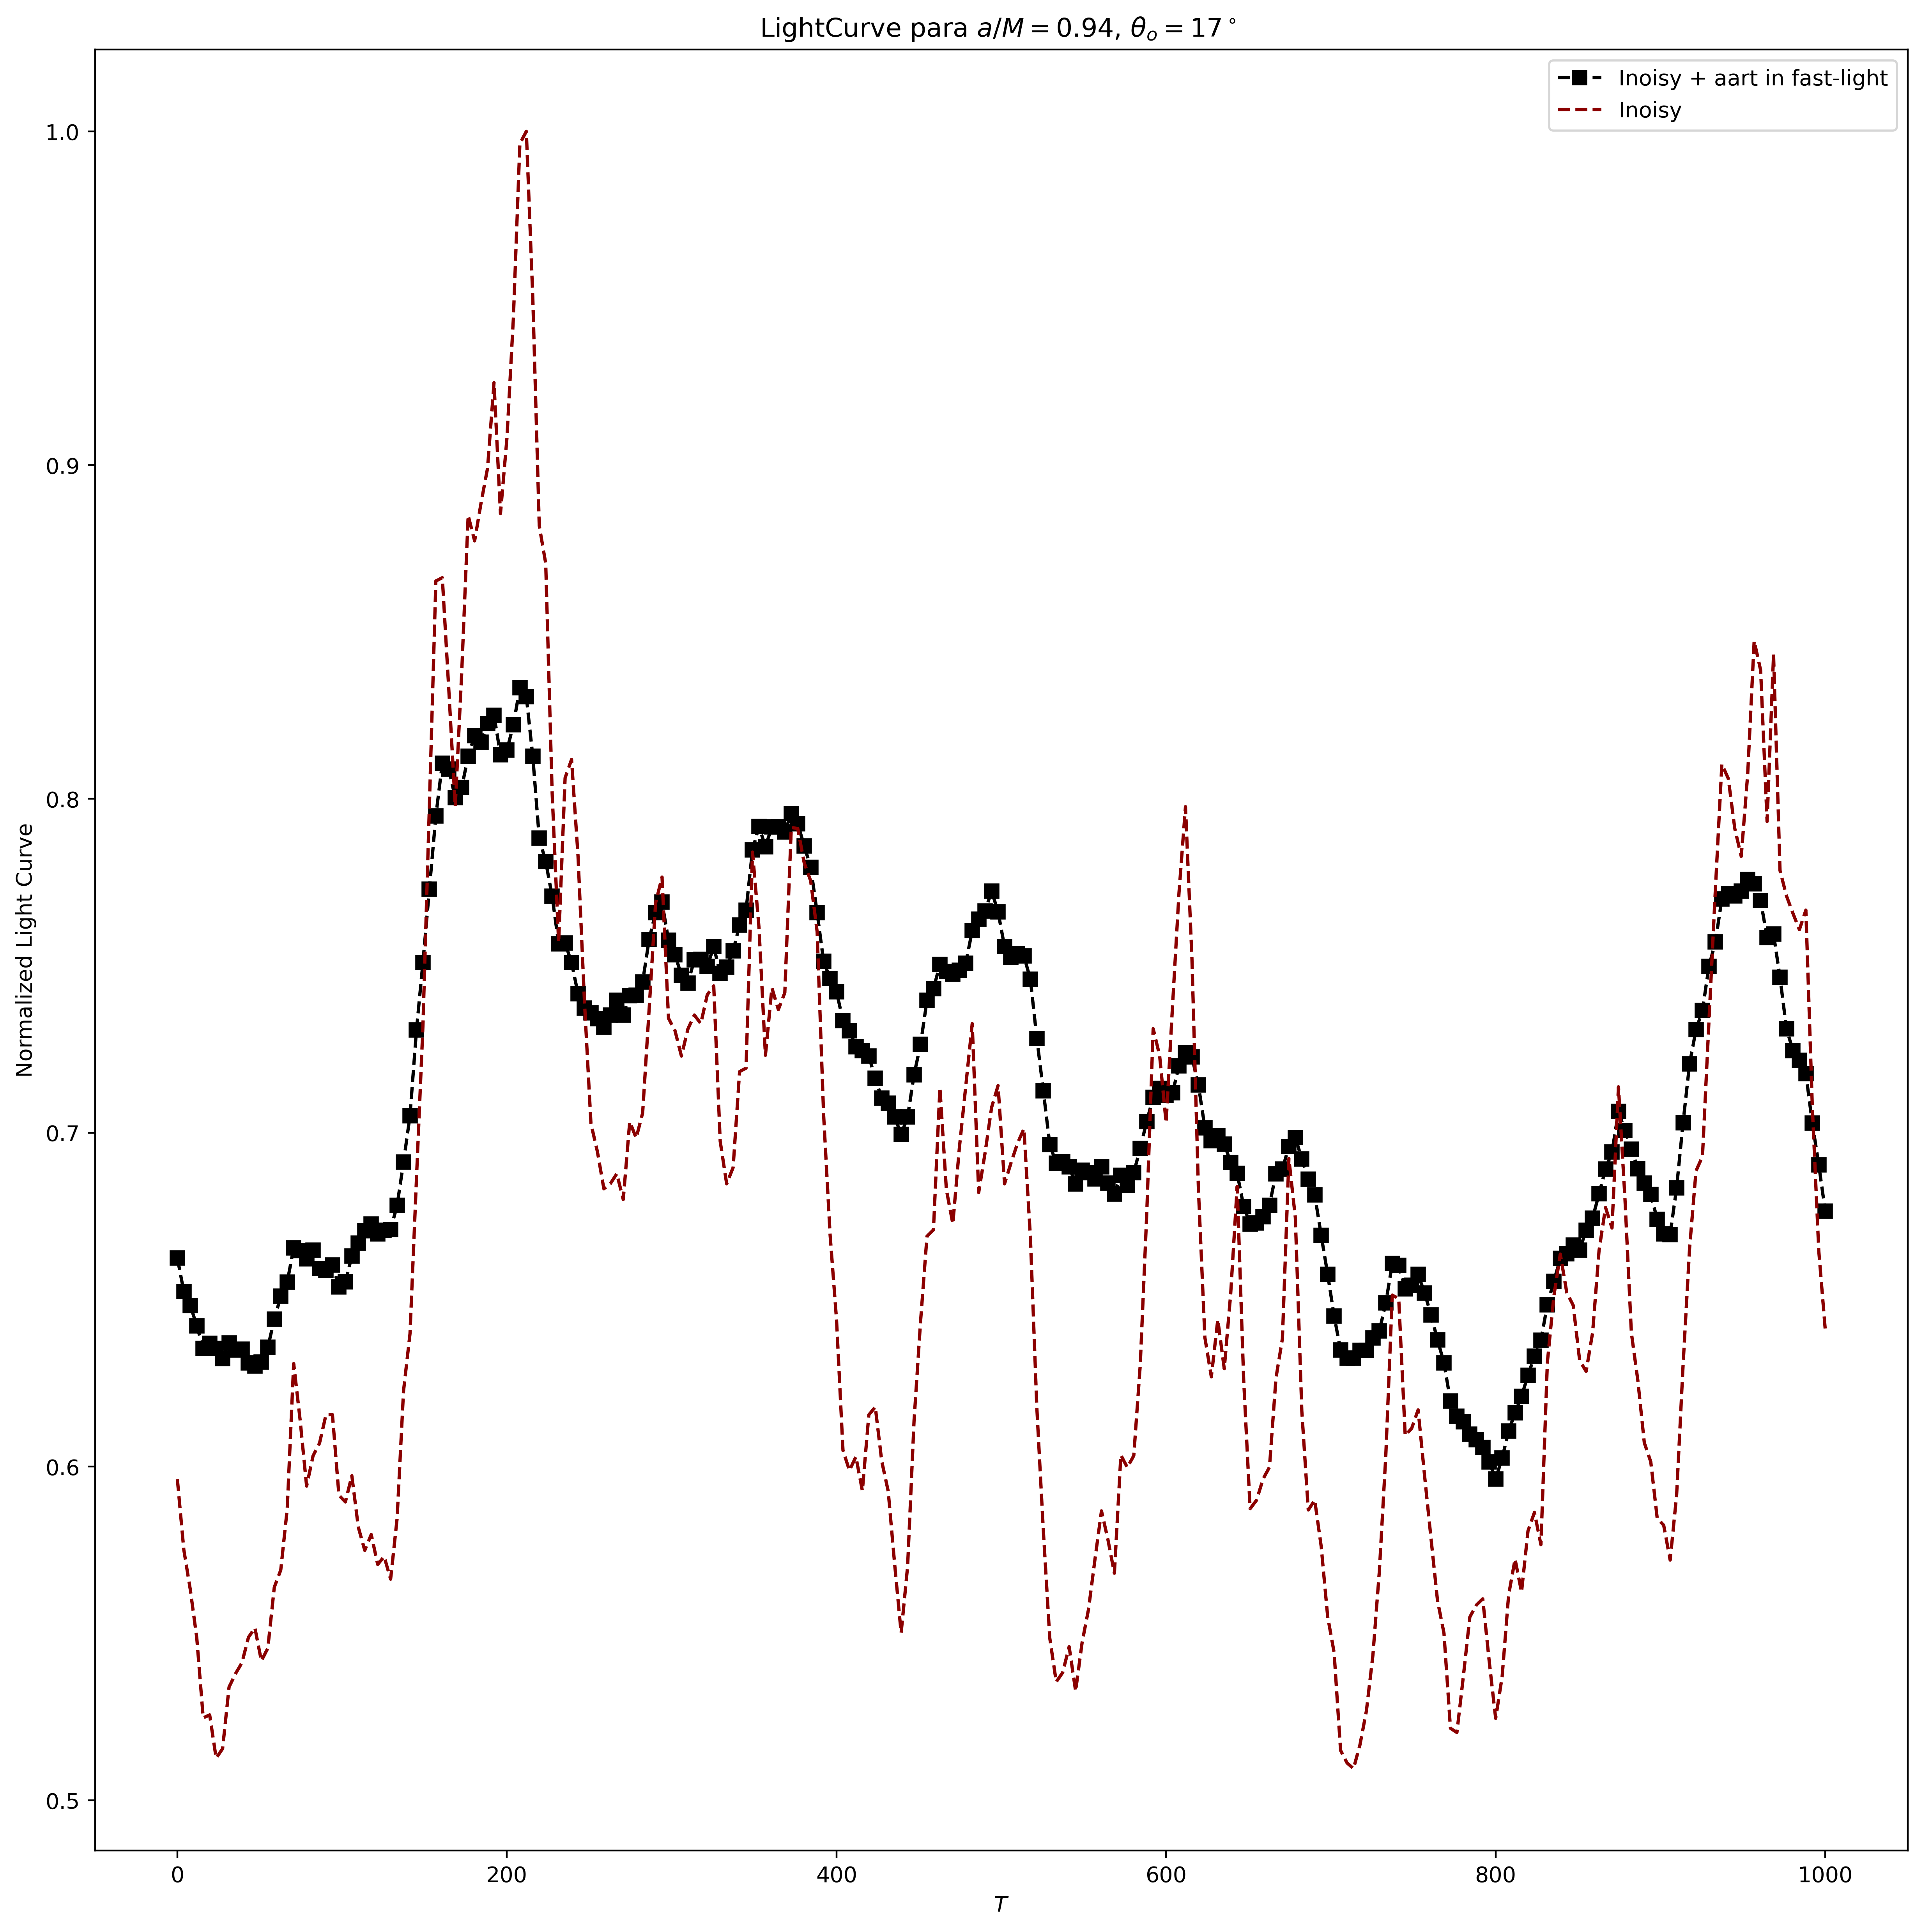

In [30]:
plt.figure(figsize=(15,15),dpi=400)

plt.plot(T_LightCurve_arrt,Light_NormalCurve_fast, 's--r', label ='Inoisy + aart in fast-light' , color = 'k')
plt.plot(np.linspace(i_tM,f_tM,256),Light_MCurve, linestyle="--", label ='Inoisy' , color = 'darkred')
plt.xlabel(r"$T$")
plt.ylabel(r"Normalized Light Curve")
plt.title(rf'LightCurve para $a/M = {spin_case}$, $\theta_o = {i_case}^\circ$ ')
plt.legend()
plt.savefig(f"./Results/Imagenes/LightCurve_{spin_case}_{i_case}_inoisyVSfast.png",dpi=400,bbox_inches='tight')
plt.show()

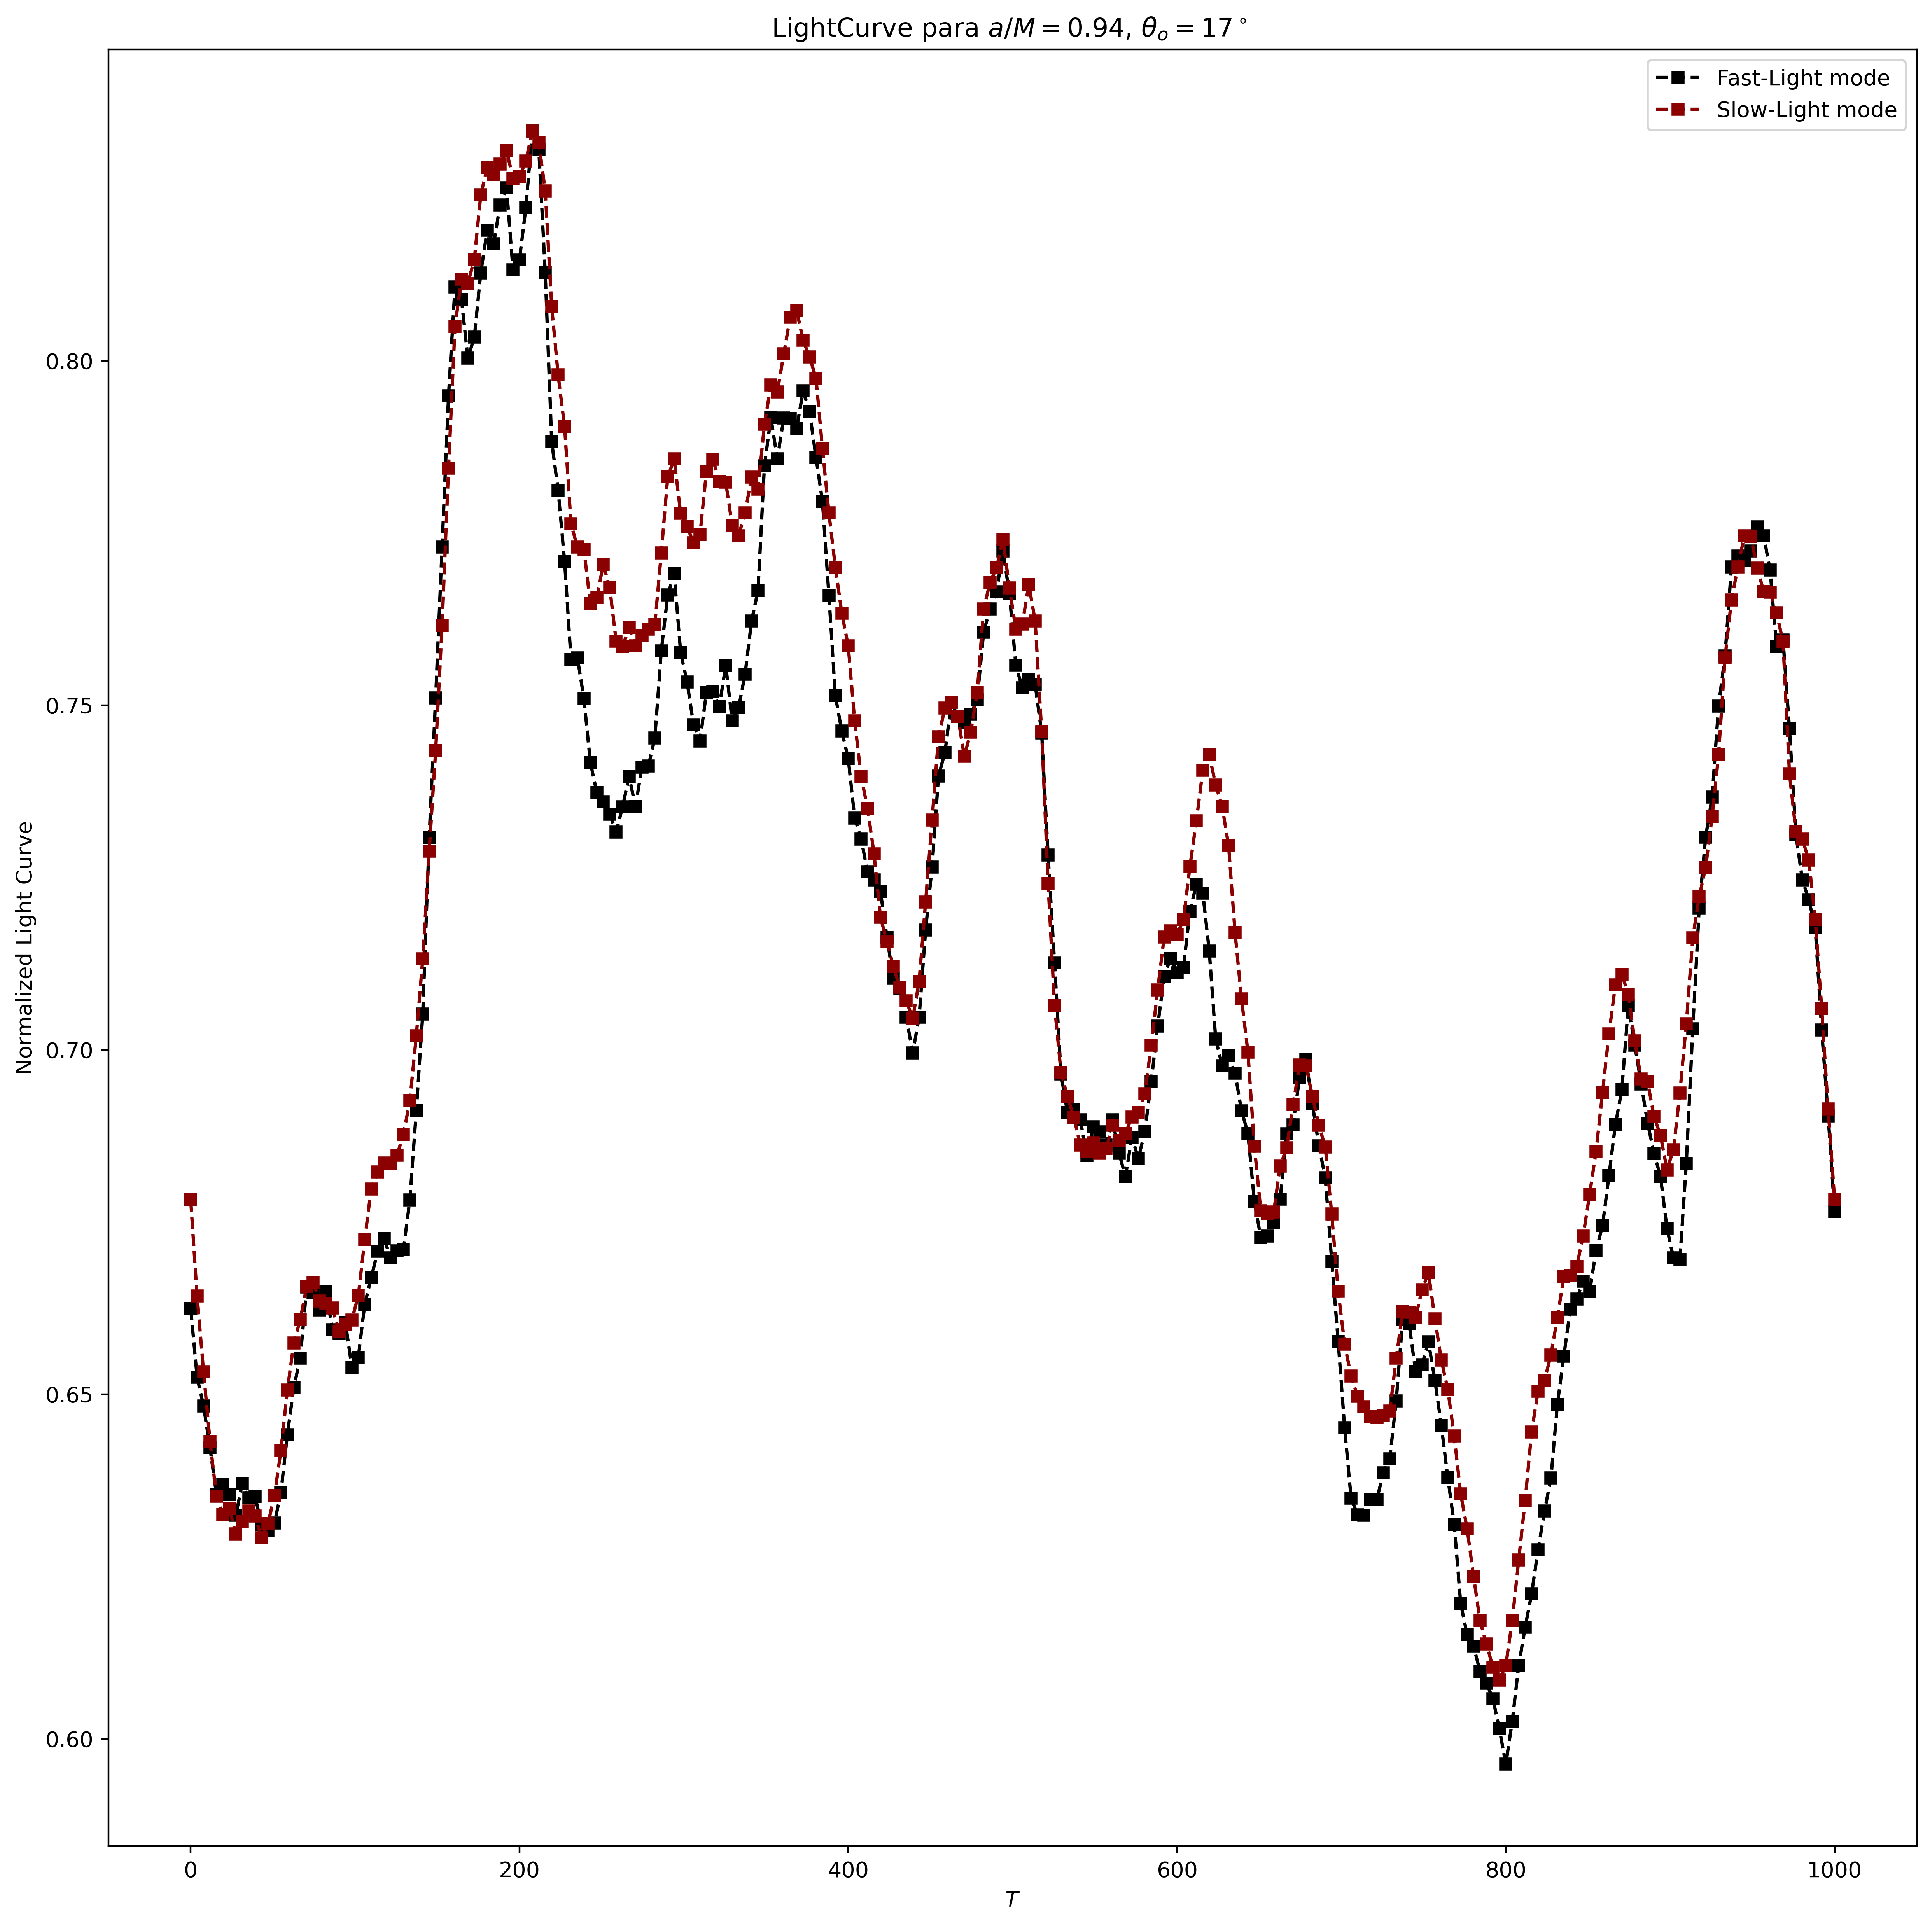

In [37]:
plt.figure(figsize=(15,15),dpi=400)

plt.plot(T_LightCurve_arrt,Light_NormalCurve_fast, 's--r', label ='Fast-Light mode' , color = 'k',markersize=5)
plt.plot(T_LightCurve_arrt,Light_NormalCurve_aart, 's--r', label ='Slow-Light mode' , color = 'darkred',markersize=5)
plt.xlabel(r"$T$")
plt.ylabel(r"Normalized Light Curve")
plt.title(rf'LightCurve para $a/M = {spin_case}$, $\theta_o = {i_case}^\circ$ ')
plt.legend()
plt.savefig(f"./Results/Imagenes/LightCurve_{spin_case}_{i_case}_fastVSslow.png",dpi=400,bbox_inches='tight')
plt.show()

## Analisis de datos

In [34]:
import pandas as pd 
dx = 0.8
path = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx{dx}_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
data = pd.read_csv(path)

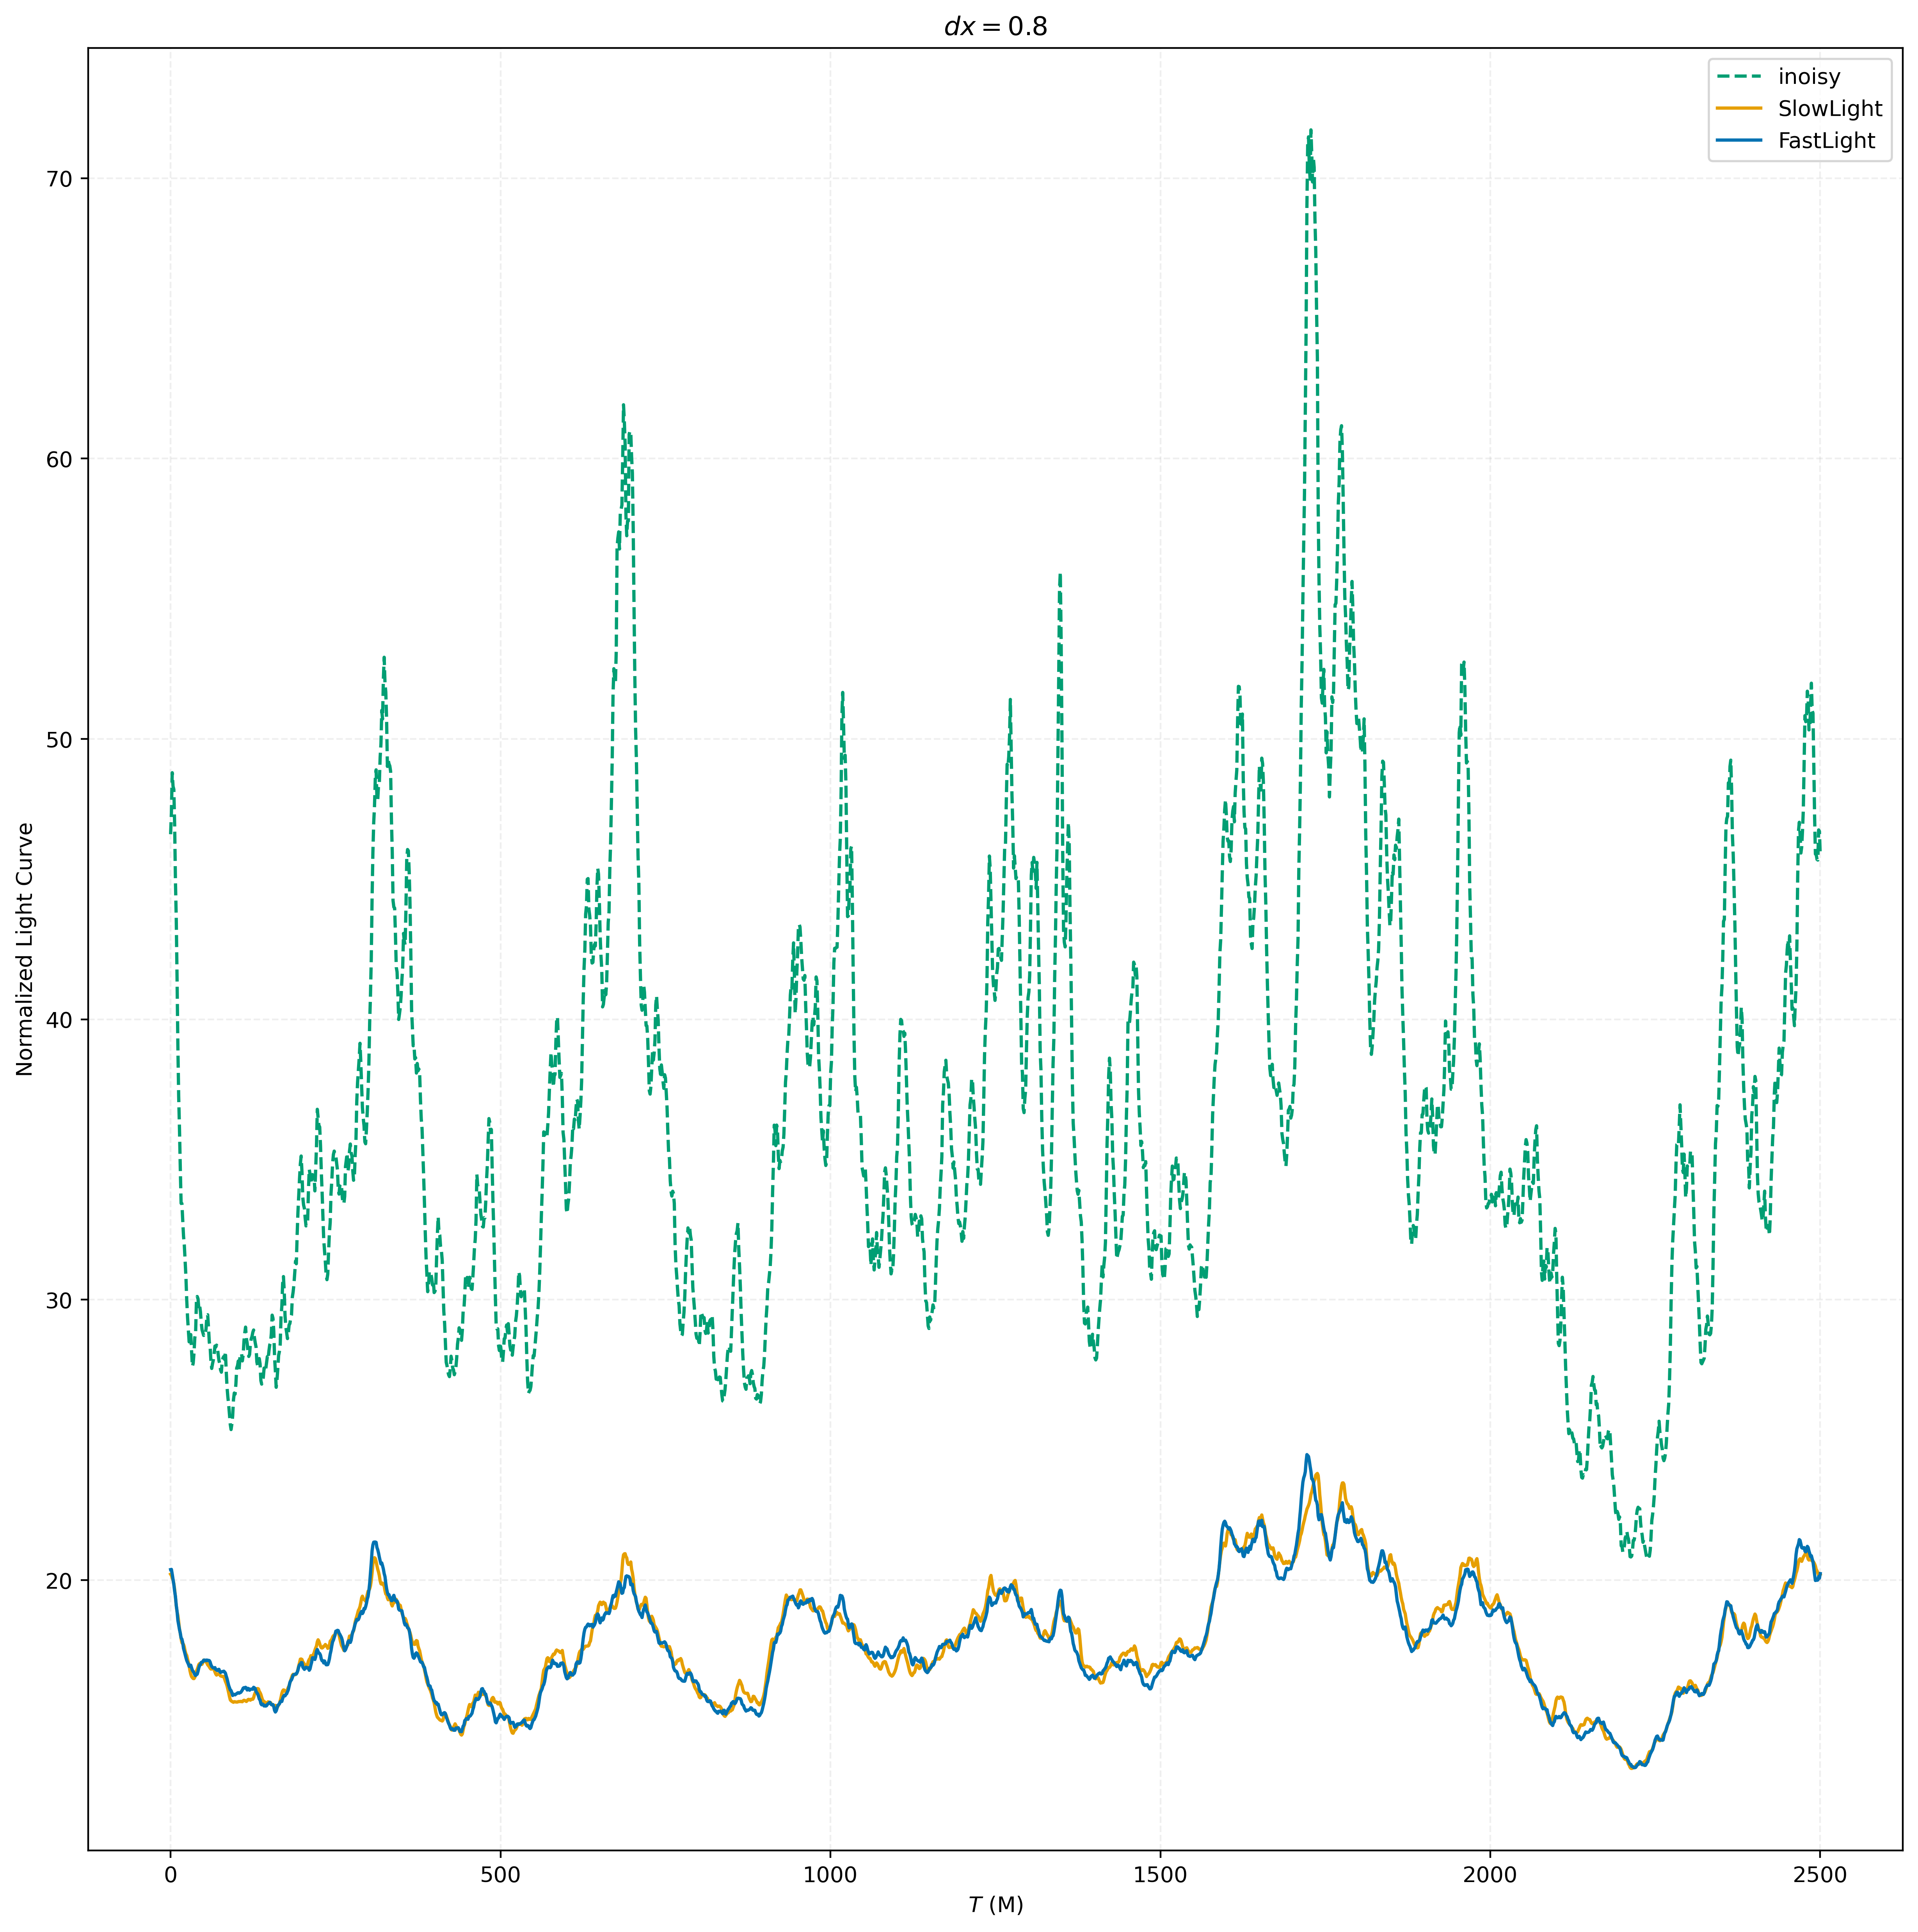

In [36]:
import matplotlib.pyplot as plt
import numpy as np
lc_inoisy    = data["inoisy"]
lc_slowlight = data["SlowLight"]
lc_fastlight = data["FastLight"]
plt.figure(figsize=(15,15),dpi=400)

plt.plot(data["Time"],lc_inoisy,color="#009E73",label="inoisy",linestyle="--")
plt.plot(data["Time"],lc_slowlight,color="#E69F00",label="SlowLight")
plt.plot(data["Time"],lc_fastlight,color="#0072B2",label="FastLight")
plt.xlabel(r"$T$"+" "+"(M)")
plt.ylabel(r"Normalized Light Curve")
plt.title(f"$dx = {dx} $")
plt.grid(linestyle="--",alpha=0.2)
plt.legend()
#plt.savefig(rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LC_{dx}.png")
plt.show()

In [12]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 

path_08 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.08_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
path_1 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.1_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
path_2 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.2_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
path_4 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.4_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
path_6 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.6_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"
path_8 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\LightCurve_datas_dx0.8_a0.94_i17.0_inoisy_n0.2_i0.94_ft2500_snap2048.csv"

data_08 = pd.read_csv(path_08)
data_1 = pd.read_csv(path_1)
data_2 = pd.read_csv(path_2)
data_4 = pd.read_csv(path_4)
data_6 = pd.read_csv(path_6)
data_8 = pd.read_csv(path_8)

In [22]:
data_08

,inoisy,SlowLight,FastLight,Time
0,46.602710,2004.218555,1986.509213,0.000000
1,47.392976,1995.530008,1988.608045,1.221299
2,48.795995,1982.049120,1990.043593,2.442599
3,48.309892,1965.313476,1978.261972,3.663898
4,48.201757,1949.008793,1958.407186,4.885198
...,...,...,...,...
2043,45.701910,2013.163393,1977.127862,2495.114802
2044,45.681300,2014.547466,1976.976714,2496.336102
2045,46.755032,2010.958930,1987.544367,2497.557401
2046,46.706023,2006.610110,1982.262287,2498.778701


In [14]:
#--------------------------------- Estandarización
def estand(f):
    return (f-np.mean(f))/np.std(f)
#--------------------------------- DISTANCIAS L1 Y L2

def distancia_L2(f, g, x):
    return np.sqrt(simpson((f - g)**2, x))

def distancia_L1(f, g, x):
    return simpson(np.abs(f - g), x)

#----------------------------- CORRELACIÓN DE PEARSON FUNCIONAL

def pearson_funcional(f, g, x):
    f_mean = simpson(f, x) / (x[len(x)-1] - x[0])
    g_mean = simpson(g, x) / (x[len(x)-1] - x[0])
    numerator = simpson((f - f_mean) * (g - g_mean), x)
    denominator = np.sqrt(simpson((f - f_mean)**2, x) * simpson((g - g_mean)**2, x))
    return numerator / denominator


In [16]:
def tabla(data_08,dx):
    L2_slow08 = distancia_L2(estand(data_08["inoisy"]), estand(data_08["SlowLight"]), estand(data_08["Time"]))
    L2_fast08 = distancia_L2(estand(data_08["inoisy"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    L2_fs08   = distancia_L2(estand(data_08["SlowLight"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    
    L1_slow08 = distancia_L1(estand(data_08["inoisy"]), estand(data_08["SlowLight"]), estand(data_08["Time"]))
    L1_fast08 = distancia_L1(estand(data_08["inoisy"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    L1_fs08   = distancia_L1(estand(data_08["SlowLight"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    
    corr_slow08 = pearson_funcional(estand(data_08["inoisy"]), estand(data_08["SlowLight"]), estand(data_08["Time"]))
    corr_fast08 = pearson_funcional(estand(data_08["inoisy"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    corr_fs08   = pearson_funcional(estand(data_08["SlowLight"]), estand(data_08["FastLight"]), estand(data_08["Time"]))
    
    #---------------------------- IMPRESIÓN DE RESULTADOS
    print(f"Métricas de comparación para {dx}:")
    print(f"""
    | Métrica               |   inoisy vs slow light   |   inoisy vs fast light   |   slow light vs fast light   |
    |-----------------------|--------------------------|--------------------------|------------------------------|
    | Distancia L²          | {L2_slow08:.4f}                   | {L2_fast08:.4f}                   | {L2_fs08:.4f}                       |
    | Distancia L¹          | {L1_slow08:.4f}                   | {L1_fast08:.4f}                   | {L1_fs08:.4f}                       |
    | Correlación Pearson   | {corr_slow08:.4f}                   | {corr_fast08:.4f}                   | {corr_fs08:.4f}                       |
    """)

In [18]:
tabla(data_08,0.08)
tabla(data_1,0.1)
tabla(data_2,0.2) 
tabla(data_4,0.4)
tabla(data_6,0.6)
tabla(data_8,0.8)

Métricas de comparación para 0.08:

    | Métrica               |   inoisy vs slow light   |   inoisy vs fast light   |   slow light vs fast light   |
    |-----------------------|--------------------------|--------------------------|------------------------------|
    | Distancia L²          | 0.9480                   | 0.8747                   | 0.3112                       |
    | Distancia L¹          | 1.3694                   | 1.2678                   | 0.4410                       |
    | Correlación Pearson   | 0.8702                   | 0.8895                   | 0.9860                       |
    
Métricas de comparación para 0.1:

    | Métrica               |   inoisy vs slow light   |   inoisy vs fast light   |   slow light vs fast light   |
    |-----------------------|--------------------------|--------------------------|------------------------------|
    | Distancia L²          | 0.9486                   | 0.8764                   | 0.3108                       |
    